# Análisis de canciones de Spotify

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Cargamos el dataset usando una ruta relativa al proyecto
csv_path = Path.cwd().parent / 'Dataset' / 'spotify-tracks.csv'
data = pd.read_csv(csv_path)

# Eliminamos la columna Unnamed: 0 (indice generado al exportar)
df = data.drop(['Unnamed: 0'], axis=1)
df = df.drop_duplicates(subset=['track_name'])  # eliminamos filas duplicadas
df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
#sorteamos las canciones por popularidad y nos quedamos con las 10 mas populares
top_100 = df.sort_values(by='popularity', ascending=False).head(100)


In [3]:
#contamos cuantas canciones explicitas hay en las 100 mas populares con la columna explicit, donde 1 es explicita y 0 no lo es ya que es un booleano
top_100['explicit'].sum()

np.int64(35)

In [4]:
generos = top_100['track_genre'].value_counts()

print(generos)

track_genre
pop            17
dance          14
latino         14
hip-hop        13
latin          12
garage          4
piano           3
alt-rock        3
rock            2
k-pop           2
hard-rock       2
indie-pop       2
alternative     2
chill           1
indie           1
funk            1
indian          1
soul            1
emo             1
synth-pop       1
country         1
british         1
reggae          1
Name: count, dtype: int64


In [5]:
d_mean = top_100['danceability'].mean()
print(f"Mean danceability: {d_mean:.3f}")

Mean danceability: 0.672


#Graficos`

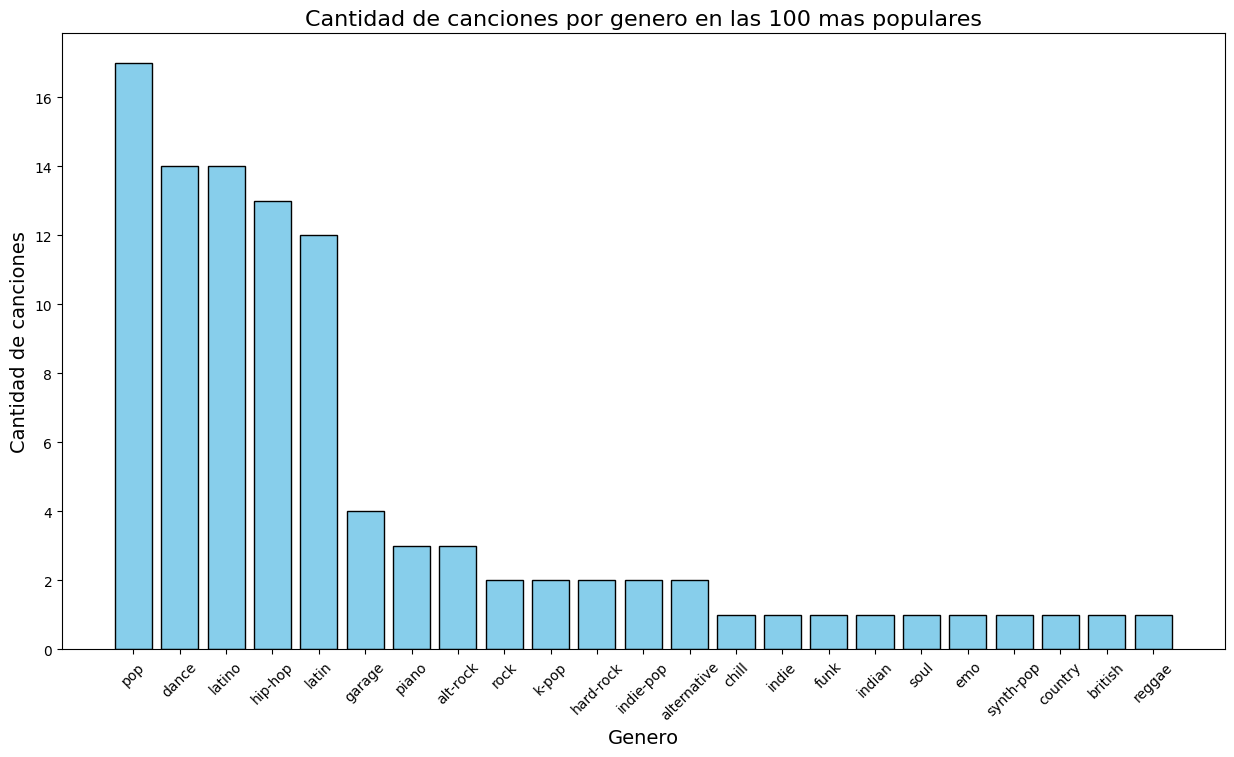

In [6]:

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.bar(generos.index, generos.values, color='skyblue', edgecolor='black', )
plt.title('Cantidad de canciones por genero en las 100 mas populares', fontsize=16)
plt.xlabel('Genero', fontsize=14)
plt.ylabel('Cantidad de canciones', fontsize=14)
ax = plt.gca()
ax.tick_params("x", rotation=45)
ax.yaxis.get_major_locator().set_params(integer=True)
plt.show()

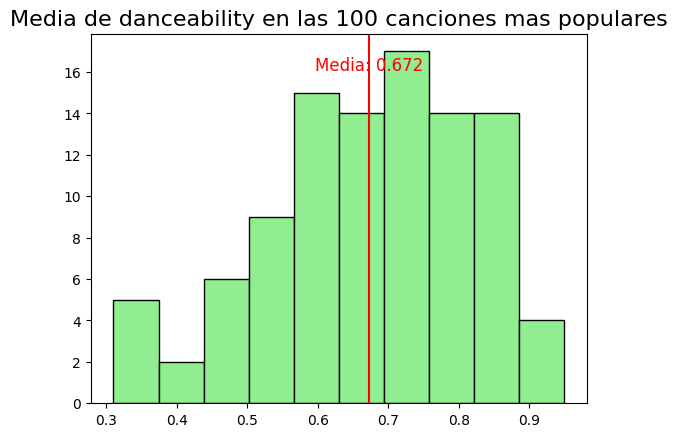

In [7]:
x=d_mean
plt.title('Media de danceability en las 100 canciones mas populares', fontsize=16)
plt.hist(x=top_100['danceability'], bins=10, color='lightgreen', edgecolor='black') #histograma de la columna danceability
plt.axvline(x=x, color='r', linestyle='-') #linea vertical en la media
plt.text(x, plt.ylim()[1]*0.9, f'Media: {x:.3f}', color='r', fontsize=12, ha='center') #texto con la media
plt.show()

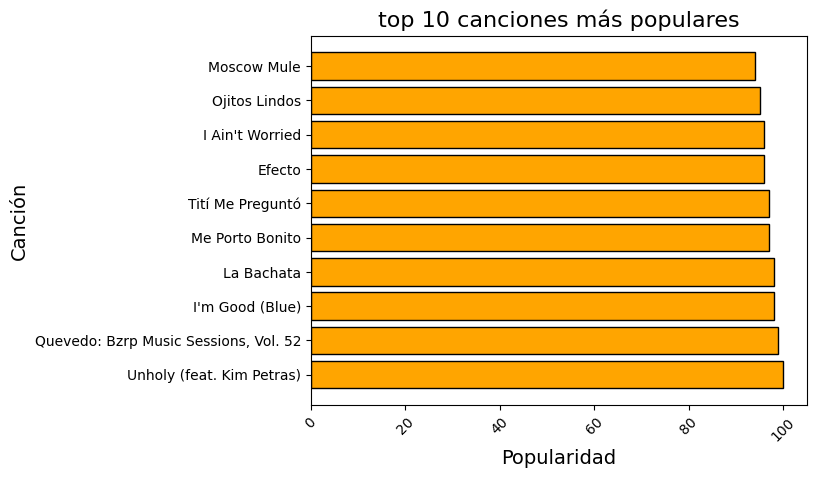

In [9]:
plt.title('top 10 canciones más populares', fontsize=16)
ax = plt.gca()
ax.tick_params("x", rotation=45)
ax.barh(top_100['track_name'][:10], top_100['popularity'][:10], color='orange', edgecolor='black')
plt.xlabel('Popularidad', fontsize=14)
plt.ylabel('Canción', fontsize=14)
plt.show()